# 01 EDA（探索的データ分析）

**目的**: データの中身を眺めて、モデル作りのヒントを集める。

EDA = Exploratory Data Analysis（探索的データ分析）

---

## このノートブックでやること

1. データを読み込む
2. 全体像を把握する
3. 欠損値を確認する
4. 生存率（`survived`）と各特徴量の関係を見る
5. 気づいたことをメモする

---

## ヒント

### データ読み込み
- `from analysis_titanic.load_data import load_train`
- `df = load_train()`

### まず見るとよいもの
- `df.head()` … 先頭5行
- `df.info()` … 列の型・欠損
- `df.describe()` … 数値列の概要
- `df.isna().sum()` … 欠損の数

### 列の意味

| 列 | 意味 |
|---|---|
| `survived` | 生存したか（1=生存, 0=死亡）← 予測したい答え |
| `pclass` | 客室クラス（1=上等, 3=下等） |
| `sex` | 性別 |
| `age` | 年齢 |
| `sibsp` | 同乗の兄弟・配偶者の数 |
| `parch` | 同乗の親・子の数 |
| `fare` | 運賃 |
| `embarked` | 乗船港（C/Q/S） |

### グラフの例（やってみる項目）
- 生存 / 死亡 の件数（棒グラフ）
- 性別・客室クラスごとの生存率
- 年齢・運賃の分布（ヒストグラム）
- 数値列同士の相関（ヒートマップ）

日本語ラベルが必要なら `import japanize_matplotlib` を使う。

### 最後にメモする例
- 欠損が多い列はどれか？
- 生存率が高そうな特徴は？
- 次の前処理で何を考える必要がある？

---

**次へ**: `02_baseline_model.ipynb`

In [2]:
# ここから自分でコードを書いていく
# 例: import → load_train() → df.head() など

from analysis_titanic.load_data import load_train
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語ラベル用（任意）

df_titanic = load_train()
df_titanic.head()

numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

In [4]:
df_titanic.columns

Index(['id', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='str')

In [3]:
df_titanic.describe()

,id,survived,pclass,age,sibsp,parch,fare
count,445.000000,445.000000,445.000000,360.000000,445.000000,445.000000,445.000000
mean,456.002247,0.402247,2.296629,29.211583,0.546067,0.431461,33.959971
std,256.703351,0.490903,0.834024,14.154300,1.195247,0.850489,52.079492
min,3.000000,0.000000,1.000000,0.670000,0.000000,0.000000,0.000000
25%,227.000000,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,463.000000,0.000000,3.000000,28.000000,0.000000,0.000000,15.000000
75%,679.000000,1.000000,3.000000,37.250000,1.000000,1.000000,31.387500
max,888.000000,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


In [23]:
df_titanic.isna().sum()

id           0
survived     0
pclass       0
sex          0
age         85
sibsp        0
parch        0
fare         0
embarked     2
dtype: int64

## pclass （客室クラス）について

In [5]:
# pclassのユニークキーを調べる
df_titanic["pclass"].unique()
df_titanic["pclass"].value_counts()

pclass
3    240
1    108
2     97
Name: count, dtype: int64

## age （年齢）について

In [6]:
df_titanic["age"].unique()

array([35.  ,  2.  , 14.  , 58.  , 39.  ,   nan, 28.  ,  8.  , 38.  ,
       66.  , 27.  ,  3.  , 19.  , 29.  , 21.  , 28.5 ,  5.  , 11.  ,
        4.  , 26.  , 32.  , 22.  , 17.  , 16.  , 23.  , 20.  , 59.  ,
       34.  , 47.  , 14.5 , 32.5 , 12.  , 45.  , 33.  , 25.  , 37.  ,
       24.  ,  9.  , 36.5 , 42.  , 55.5 , 40.5 , 44.  ,  1.  , 56.  ,
       50.  , 36.  , 45.5 , 40.  , 30.  , 20.5 , 18.  , 41.  , 63.  ,
       65.  , 23.5 ,  0.92, 43.  , 61.  , 31.  , 10.  , 64.  , 13.  ,
       52.  , 48.  ,  0.75, 62.  , 53.  , 54.  , 49.  , 80.  , 60.  ,
       15.  , 70.  ,  6.  ,  0.67, 51.  , 30.5 , 57.  , 46.  ,  0.83])

In [34]:
df_titanic["age"].value_counts()

age
24.00    15
36.00    15
22.00    14
30.00    14
19.00    13
         ..
0.67      1
51.00     1
57.00     1
46.00     1
0.83      1
Name: count, Length: 80, dtype: int64

In [33]:
# 欠損値の確認
missing_count = df_titanic["age"].isna().sum()
total_count = len(df_titanic)

print(f"欠損: {missing_count} 件")
print(f"全体: {total_count} 件")
print(f"割合: {missing_count / total_count:.1%}")

欠損: 85 件
全体: 445 件
割合: 19.1%


In [24]:
df_titanic[df_titanic["age"].isna()]

,id,survived,pclass,sex,age,sibsp,parch,fare,embarked
7,19,1,3,female,NaN,0,0,7.2250,C
11,26,0,3,male,NaN,0,0,7.2250,C
12,28,1,3,female,NaN,0,0,7.8792,Q
13,29,0,3,male,NaN,0,0,7.8958,S
14,32,1,3,female,NaN,0,0,7.7500,Q
...,...,...,...,...,...,...,...,...,...
422,846,0,3,male,NaN,8,2,69.5500,S
424,849,1,1,female,NaN,1,0,89.1042,C
433,863,0,3,female,NaN,8,2,69.5500,S
436,868,0,3,male,NaN,0,0,9.5000,S


In [29]:
# 性別と客室クラスごとの年齢の中央値を算出する
df_titanic.groupby(["sex", "pclass"])["age"].median()

sex     pclass
female  1         34.0
        2         27.5
        3         22.0
male    1         37.0
        2         30.0
        3         26.0
Name: age, dtype: float64

In [32]:
# 欠損値を埋める
# 年齢と相関が高そうな客室クラスと性別の中央値で埋める
df_titanic_cred = df_titanic.copy()
df_titanic_cred["age"] = (
    df_titanic.groupby(["sex", "pclass"])["age"]
    .transform(
        lambda s: s.fillna(s.median())
    )
)
print("埋める前:", df_titanic["age"].isna().sum())
print("埋めた後:", df_titanic_cred["age"].isna().sum())

埋める前: 85
埋めた後: 0


## sex について

In [13]:
df_titanic["sex"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [20]:
df_titanic["sex"].value_counts()

sex
male      289
female    156
Name: count, dtype: int64

## age_sex について
age と sex の特徴量から新規特徴量を作成する

In [ ]:
# age と sex で新たな特徴量を作成する
df["age_sex"] = 

## sibsp について
兄弟・姉妹・義兄弟・異母兄弟・配偶者（夫・妻）

親しき人がいるか？

In [7]:
df_titanic["sibsp"].value_counts()

sibsp
0    299
1    111
2     14
4      7
3      6
8      6
5      2
Name: count, dtype: int64

## parch について
両親、子ども（息子・娘、義理の息子・娘）

守る人がいるか？

In [14]:
df_titanic["parch"].value_counts()

parch
0    330
1     56
2     49
3      5
5      3
4      2
Name: count, dtype: int64

## fare について
チケット料

In [9]:
df_titanic["fare"]

0      53.1000
1       8.0500
2      21.0750
3      30.0708
4      26.5500
        ...   
440     9.0000
441    24.0000
442    83.1583
443     7.0500
444    23.4500
Name: fare, Length: 445, dtype: float64

## embarked について
乗船港（Port of Embarkation）
C = Cherbourg（仏）：シェブール（フランス）
Q = Queenstown（愛）：クイーンズタウン（アイルランド）
S = Southampton（英）：サウザンプトン（イギリス）
1912年4月10日：サウザンプトン出向
同日：シェブールへ寄港
4月11日：クイーンズタウンへ寄港
同日：最終目的地（大西洋横断）※へ出向
※アメリカのニューヨークへ

各乗船港における乗客の特徴
サウザンプトン：一般客・乗組員中心
シェブール：富裕層（一等客）
クイーンズタウン：移住目的


In [10]:
df_titanic["embarked"]

0      S
1      S
2      S
3      C
4      S
      ..
440    S
441    C
442    C
443    S
444    S
Name: embarked, Length: 445, dtype: str

## 全体について
生存と客室クラスはそれなりに相関関係がありそう。

In [11]:
# 全体の相関値を算出し、可視化する
corr = df_titanic[numeric_cols].corr()
corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.358097,-0.081394,-0.045087,0.079669,0.258605
pclass,-0.358097,1.000000,-0.300686,0.069857,-0.015726,-0.549651
age,-0.081394,-0.300686,1.000000,-0.283126,-0.153382,0.098488
sibsp,-0.045087,0.069857,-0.283126,1.000000,0.423522,0.164773
parch,0.079669,-0.015726,-0.153382,0.423522,1.000000,0.241855
fare,0.258605,-0.549651,0.098488,0.164773,0.241855,1.000000


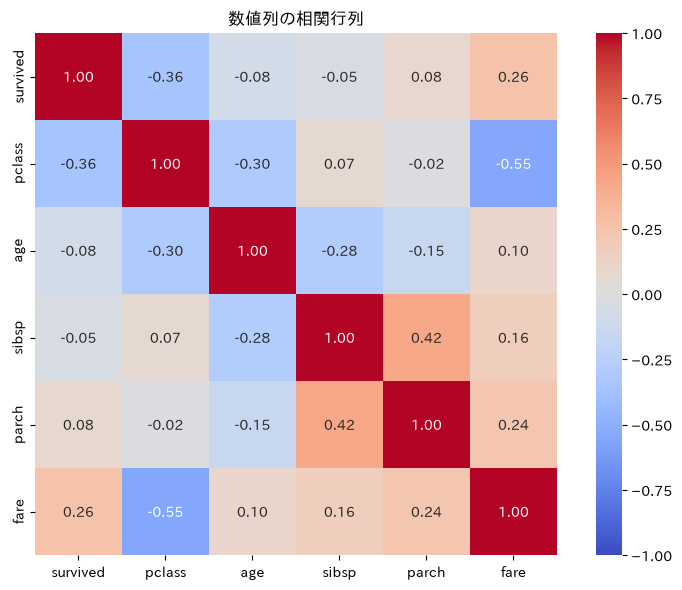

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,      # 数値をセルに表示
    fmt=".2f",       # 小数2桁
    cmap="coolwarm", # 色（赤=正、青=負）
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("数値列の相関行列")
plt.tight_layout()
plt.show()